In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from itertools import product

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

Device: cpu


In [2]:
g = 9.81

# Training range — network learns ALL (u, theta) combinations in this box
u_min,     u_max     = 15.0, 35.0       # launch speed range (m/s)
theta_min, theta_max = 20.0, 70.0       # launch angle range (degrees)

# Reference values for normalisation
u_ref     = u_max                        # normalise u to [u_min/u_ref, 1]
theta_ref = np.pi / 2                    # normalise theta to [0, 1]
y_ref     = (u_max * np.sin(np.radians(theta_max)))**2 / (2 * g)  # max possible height

print(f"Training u range    : {u_min} – {u_max} m/s")
print(f"Training theta range: {theta_min} – {theta_max} degrees")
print(f"y_ref (max height)  : {y_ref:.2f} m")


Training u range    : 15.0 – 35.0 m/s
Training theta range: 20.0 – 70.0 degrees
y_ref (max height)  : 55.13 m


In [3]:
def analytical_y(x, u, theta_deg):
    """True parabolic solution for given launch conditions."""
    theta = np.radians(theta_deg)
    vx = u * np.cos(theta)
    vy = u * np.sin(theta)
    return (vy / vx) * x - (g / (2 * vx**2)) * x**2

def x_range_for(u, theta_deg):
    """Analytical horizontal range (where y=0 again)."""
    theta = np.radians(theta_deg)
    vx = u * np.cos(theta)
    vy = u * np.sin(theta)
    return 2 * vx * vy / g

def normalise_inputs(x_raw, u_val, theta_deg_val, x_max_val):
    """
    Normalise all inputs to roughly [0,1] range.
    x_raw      : tensor of x positions
    u_val      : scalar launch speed
    theta_deg  : scalar launch angle in degrees
    x_max_val  : the range for this (u, theta) — used to normalise x
    Returns a tensor of shape [N, 3]: [x_norm, u_norm, theta_norm]
    """
    x_norm     = x_raw / x_max_val
    u_norm     = torch.full_like(x_raw, u_val / u_ref)
    theta_norm = torch.full_like(x_raw, np.radians(theta_deg_val) / theta_ref)
    return torch.cat([x_norm, u_norm, theta_norm], dim=1)

In [4]:
# N_INPUT = 3  : [x_norm, u_norm, theta_norm]
# N_OUTPUT = 1 : y_norm
# Larger network than phase 1 — now learning a family of curves, not one.
# 5 layers x 64 neurons gives enough capacity for the (u, theta) space.

class FCN(nn.Module):
    def __init__(self, N_INPUT=3, N_OUTPUT=1, N_HIDDEN=64, N_LAYERS=5):
        super().__init__()
        activation = nn.Tanh
        layers = []
        layers.append(nn.Linear(N_INPUT, N_HIDDEN))
        layers.append(activation())
        for _ in range(N_LAYERS - 1):
            layers.append(nn.Linear(N_HIDDEN, N_HIDDEN))
            layers.append(activation())
        layers.append(nn.Linear(N_HIDDEN, N_OUTPUT))
        self.net = nn.Sequential(*layers)

    def forward(self, inp):
        return self.net(inp)   # inp shape [N, 3], output shape [N, 1]

pinn = FCN().to(device)
print(pinn)
print(f"Parameters: {sum(p.numel() for p in pinn.parameters())}")

FCN(
  (net): Sequential(
    (0): Linear(in_features=3, out_features=64, bias=True)
    (1): Tanh()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): Tanh()
    (4): Linear(in_features=64, out_features=64, bias=True)
    (5): Tanh()
    (6): Linear(in_features=64, out_features=64, bias=True)
    (7): Tanh()
    (8): Linear(in_features=64, out_features=64, bias=True)
    (9): Tanh()
    (10): Linear(in_features=64, out_features=1, bias=True)
  )
)
Parameters: 16961


In [5]:
# For generalised training we sample MANY (u, theta) combinations per batch.
# For each sampled (u, theta):
#   - IC point  : x=0, y=0, slope=vy/vx
#   - Collocation: random x in [0, x_max], physics residual enforced
#
# We regenerate points every epoch (or every K epochs) so the network
# sees a wide variety of (u, theta) pairs throughout training.
# This is called "on-the-fly" data generation and is standard for
# generalised PINNs.

num_pairs_per_epoch = 20
num_col_per_pair    = 200

def sample_training_batch():
    ic_inputs  = []
    bc_inputs  = []
    col_inputs = []

    for _ in range(num_pairs_per_epoch):
        u_s     = np.random.uniform(u_min, u_max)
        th_s    = np.random.uniform(theta_min, theta_max)
        theta_r = np.radians(th_s)
        vx_s    = u_s * np.cos(theta_r)
        vy_s    = u_s * np.sin(theta_r)
        x_max_s = x_range_for(u_s, th_s)
        phys_c  = -g / (vx_s ** 2)

        # ── IC point: x=0, y=0 ───────────────────────────────────────────
        x_ic  = torch.zeros(1, 1, requires_grad=True, device=device)
        ic_in = normalise_inputs(x_ic, u_s, th_s, x_max_s)
        slope_true = torch.tensor([[vy_s / vx_s]], dtype=torch.float32, device=device)
        ic_inputs.append((ic_in, x_ic, x_max_s, y_ref, slope_true))

        # ── BC point: x=x_max, y=0 ───────────────────────────────────────
        # x_norm = x_max / x_max = 1.0 — always the right edge
        # y_norm should be 0 here (landing)
        x_bc = torch.tensor([[x_max_s]], dtype=torch.float32, requires_grad=False, device=device)
        bc_in = normalise_inputs(x_bc, u_s, th_s, x_max_s)
        bc_inputs.append((bc_in,))                  # ← store normalised input

        # ── Collocation points: random x in [0, x_max] ───────────────────
        x_col = torch.rand(num_col_per_pair, 1, device=device) * x_max_s
        x_col.requires_grad_(True)
        col_in = normalise_inputs(x_col, u_s, th_s, x_max_s)
        col_inputs.append((col_in, x_col, x_max_s, y_ref, phys_c))

    return ic_inputs, bc_inputs, col_inputs

In [6]:
def compute_losses(ic_inputs, bc_inputs, col_inputs):  # ← bc_inputs added
    loss_ic    = torch.tensor(0.0, device=device)
    loss_slope = torch.tensor(0.0, device=device)
    loss_bc    = torch.tensor(0.0, device=device)      # ← NEW
    loss_phys  = torch.tensor(0.0, device=device)

    # ── IC loss: y(0)=0 and dy/dx(0) = vy/vx ────────────────────────────
    for (ic_in, x_ic, x_max_s, y_ref_s, slope_true) in ic_inputs:
        y_pred_ic = pinn(ic_in)
        loss_ic   = loss_ic + torch.mean(y_pred_ic ** 2)

        dy_norm_dx = torch.autograd.grad(
            y_pred_ic, x_ic,
            grad_outputs=torch.ones_like(y_pred_ic),
            create_graph=True
        )[0]
        dy_dx_phys = dy_norm_dx * y_ref_s
        loss_slope = loss_slope + torch.mean((dy_dx_phys - slope_true) ** 2)

    # ── BC loss: y(x_max)=0 ──────────────────────────────────────────────
    # y_norm at the landing point should be 0
    # No derivative needed here — just a value constraint
    for (bc_in,) in bc_inputs:
        y_pred_bc = pinn(bc_in)                        # shape [1,1]
        loss_bc   = loss_bc + torch.mean(y_pred_bc ** 2)

    # ── Physics loss: d²y/dx² = -g/vx² ───────────────────────────────────
    for (col_in, x_col_raw, x_max_s, y_ref_s, phys_c) in col_inputs:
        y_pred_col = pinn(col_in)

        dy_norm_dx = torch.autograd.grad(
            y_pred_col, x_col_raw,
            grad_outputs=torch.ones_like(y_pred_col),
            create_graph=True
        )[0]
        dy_dx_phys = dy_norm_dx * y_ref_s

        d2y_dx2_phys = torch.autograd.grad(
            dy_dx_phys, x_col_raw,
            grad_outputs=torch.ones_like(dy_dx_phys),
            create_graph=True
        )[0]

        residual  = d2y_dx2_phys - phys_c
        loss_phys = loss_phys + torch.mean(residual ** 2)

    n = num_pairs_per_epoch
    return loss_ic / n, loss_slope / n, loss_bc / n, loss_phys / n

In [7]:
lambda_ic    = 5.0
lambda_slope = 20.0
lambda_bc    = 10.0    # ← NEW — pins landing point without fighting physics
lambda_phys  = 100.0

num_epochs = 8000
optimizer  = torch.optim.Adam(pinn.parameters(), lr=5e-4)
scheduler  = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=num_epochs, eta_min=1e-6
)

loss_ic_hist    = []
loss_slope_hist = []
loss_bc_hist    = []    # ← NEW
loss_phys_hist  = []
loss_total_hist = []

checkpoints  = [0, num_epochs//4, num_epochs//2, num_epochs-1]
snap_configs = [(20.0, 45.0), (25.0, 30.0), (30.0, 60.0)]
snapshots    = {cfg: [] for cfg in snap_configs}

print("Training...")
print(f"{'Epoch':>6}  {'Total':>10}  {'IC':>10}  {'Slope':>10}  {'BC':>10}  {'Physics':>10}")

for epoch in range(num_epochs):
    optimizer.zero_grad()

    ic_inputs, bc_inputs, col_inputs = sample_training_batch()  # ← unpack 3

    loss_ic, loss_slope, loss_bc, loss_phys = compute_losses(ic_inputs=ic_inputs, bc_inputs=bc_inputs, col_inputs=col_inputs)

    loss_total = (lambda_ic    * loss_ic
                + lambda_slope * loss_slope
                + lambda_bc    * loss_bc        # ← included in total
                + lambda_phys  * loss_phys)

    loss_total.backward()
    optimizer.step()
    scheduler.step()

    loss_ic_hist.append(loss_ic.detach().cpu().item())
    loss_slope_hist.append(loss_slope.detach().cpu().item())
    loss_bc_hist.append(loss_bc.detach().cpu().item())          # ← tracked
    loss_phys_hist.append(loss_phys.detach().cpu().item())
    loss_total_hist.append(loss_total.detach().cpu().item())

    if epoch in checkpoints:
        pinn.eval()
        with torch.no_grad():
            for (u_t, th_t) in snap_configs:
                x_max_t  = x_range_for(u_t, th_t)
                x_arr    = np.linspace(0, x_max_t, 300)
                x_tensor = torch.tensor(x_arr, dtype=torch.float32,
                                        device=device).unsqueeze(1)
                inp      = normalise_inputs(x_tensor, u_t, th_t, x_max_t)
                y_norm   = pinn(inp).cpu().numpy().squeeze()
                y_pred   = y_norm * y_ref
                snapshots[(u_t, th_t)].append({
                    'epoch': epoch, 'x': x_arr, 'y_pred': y_pred,
                    'y_true': analytical_y(x_arr, u_t, th_t)
                })
        pinn.train()

    if epoch % 1000 == 0:
        print(f"{epoch:>6}  {loss_total.item():>10.3e}  "
              f"{loss_ic.item():>10.3e}  {loss_slope.item():>10.3e}  "
              f"{loss_bc.item():>10.3e}  {loss_phys.item():>10.3e}")

print("Training complete.")

Training...
 Epoch       Total          IC       Slope          BC     Physics
     0   2.972e+01   3.810e-03   1.461e+00   6.245e-03   4.193e-03
  1000   2.059e-01   3.602e-03   2.014e-03   1.410e-03   1.335e-03
  2000   8.320e-02   9.384e-04   1.107e-03   1.479e-03   4.157e-04
  3000   6.198e-02   2.670e-04   8.627e-04   5.127e-04   3.826e-04
  4000   3.109e-02   1.160e-04   2.889e-04   5.073e-04   1.966e-04
  5000   1.603e-02   5.616e-05   3.005e-04   1.298e-04   8.444e-05
  6000   1.292e-02   7.217e-05   2.208e-04   1.307e-04   6.839e-05
  7000   1.468e-02   1.007e-04   1.577e-04   7.817e-05   1.025e-04
Training complete.


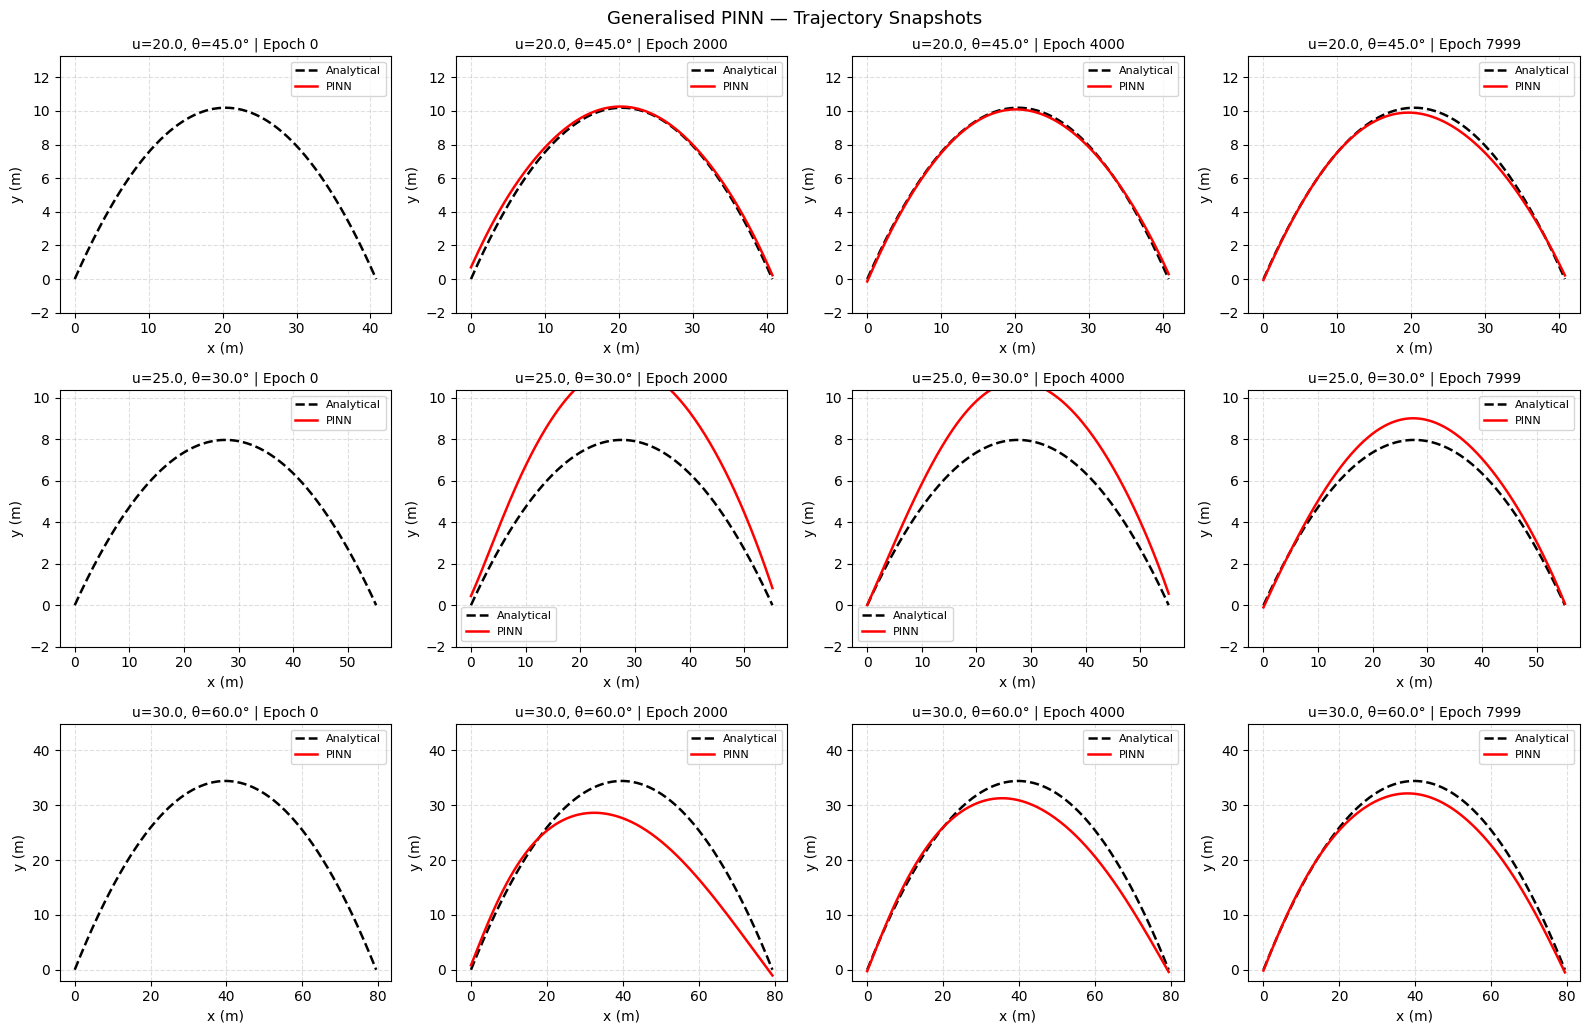

In [8]:
# One row per test (u, theta) case, one column per checkpoint epoch.

n_rows = len(snap_configs)
n_cols = len(checkpoints)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 3.5*n_rows))

for row, cfg in enumerate(snap_configs):
    u_t, th_t = cfg
    for col, snap in enumerate(snapshots[cfg]):
        ax = axes[row][col]
        ax.plot(snap['x'], snap['y_true'], 'k--', linewidth=1.8, label='Analytical')
        ax.plot(snap['x'], snap['y_pred'], 'r-',  linewidth=1.8, label='PINN')
        ax.set_title(f"u={u_t}, θ={th_t}° | Epoch {snap['epoch']}", fontsize=10)
        ax.set_xlabel("x (m)"); ax.set_ylabel("y (m)")
        ax.set_ylim(-2, snap['y_true'].max() * 1.3)
        ax.legend(fontsize=8); ax.grid(True, linestyle='--', alpha=0.4)

plt.suptitle("Generalised PINN — Trajectory Snapshots", fontsize=13)
plt.tight_layout()
plt.show()

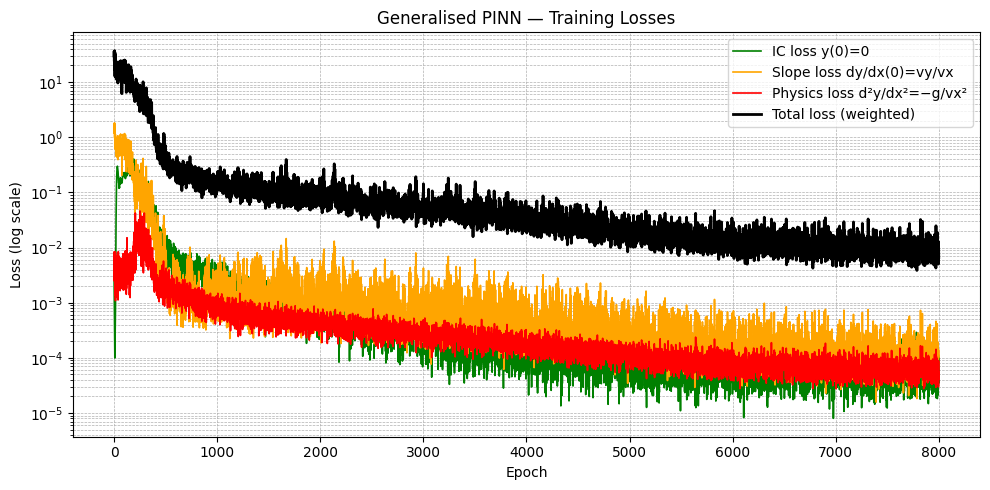

In [9]:
epochs_arr = np.arange(num_epochs)
plt.figure(figsize=(10, 5))
plt.plot(epochs_arr, loss_ic_hist,    color='green',  linewidth=1.2, label='IC loss y(0)=0')
plt.plot(epochs_arr, loss_slope_hist, color='orange', linewidth=1.2, label='Slope loss dy/dx(0)=vy/vx')
plt.plot(epochs_arr, loss_phys_hist,  color='red',    linewidth=1.2, label='Physics loss d²y/dx²=−g/vx²')
plt.plot(epochs_arr, loss_total_hist, color='black',  linewidth=2.0, label='Total loss (weighted)')
plt.yscale('log')
plt.xlabel('Epoch'); plt.ylabel('Loss (log scale)')
plt.title('Generalised PINN — Training Losses')
plt.legend(); plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.tight_layout(); plt.show()

In [10]:
# Sweep a grid of (u, theta) values — including OUTSIDE the training range —
# and compute RMSE % at each point.
# This tells you exactly where the PINN generalises and where it breaks down.

n_u     = 25    # grid resolution in u direction
n_theta = 25    # grid resolution in theta direction

# Extend slightly beyond training range to see boundary behaviour
u_sweep     = np.linspace(u_min - 5,     u_max + 5,     n_u)
theta_sweep = np.linspace(theta_min - 5, theta_max + 5, n_theta)

rmse_grid = np.zeros((n_theta, n_u))

pinn.eval()
with torch.no_grad():
    for i, th_s in enumerate(theta_sweep):
        for j, u_s in enumerate(u_sweep):
            # Skip physically invalid cases
            if th_s <= 0 or th_s >= 90 or u_s <= 0:
                rmse_grid[i, j] = np.nan
                continue

            x_max_s  = x_range_for(u_s, th_s)
            x_arr    = np.linspace(0, x_max_s, 200)
            y_true_s = analytical_y(x_arr, u_s, th_s)

            x_tensor = torch.tensor(x_arr, dtype=torch.float32,
                                    device=device).unsqueeze(1)
            inp      = normalise_inputs(x_tensor, u_s, th_s, x_max_s)
            y_norm   = pinn(inp).cpu().numpy().squeeze()
            y_pred_s = y_norm * y_ref

            y_max    = y_true_s.max()
            if y_max < 1e-6:
                rmse_grid[i, j] = np.nan
                continue

            rmse     = np.sqrt(np.mean((y_pred_s - y_true_s)**2))
            rmse_pct = rmse / y_max * 100
            rmse_grid[i, j] = rmse_pct

pinn.train()

print(f"\nSensitivity Analysis Results:")
print(f"  Mean RMSE across grid : {np.nanmean(rmse_grid):.2f}%")
print(f"  Min RMSE              : {np.nanmin(rmse_grid):.2f}%")
print(f"  Max RMSE              : {np.nanmax(rmse_grid):.2f}%")

# Points inside training range below threshold
threshold = 5.0
inside_mask = ((u_sweep[np.newaxis, :] >= u_min) &
               (u_sweep[np.newaxis, :] <= u_max) &
               (theta_sweep[:, np.newaxis] >= theta_min) &
               (theta_sweep[:, np.newaxis] <= theta_max))
inside_valid = rmse_grid[inside_mask & ~np.isnan(rmse_grid)]
pct_passing  = np.mean(inside_valid < threshold) * 100
print(f"  % of training range below {threshold}% RMSE: {pct_passing:.1f}%")


Sensitivity Analysis Results:
  Mean RMSE across grid : 21.06%
  Min RMSE              : 0.95%
  Max RMSE              : 397.13%
  % of training range below 5.0% RMSE: 55.7%


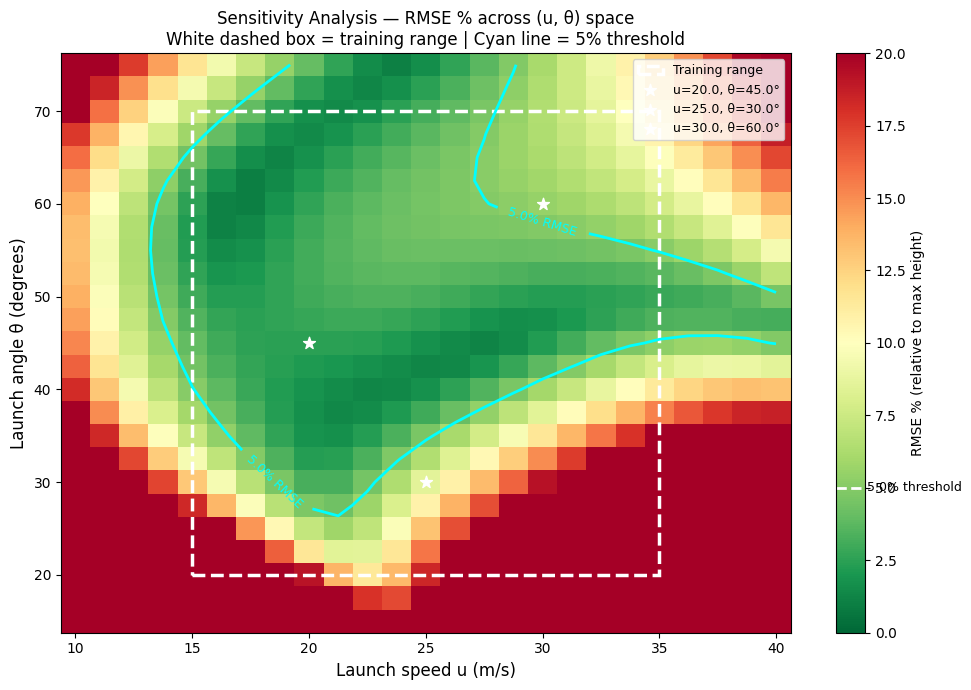

In [13]:
fig, ax = plt.subplots(figsize=(10, 7))

# Use a diverging colormap centred at the threshold
cmap = plt.cm.RdYlGn_r
vmin, vmax = 0, 20   # clip display at 20% for readability

im = ax.pcolormesh(
    u_sweep, theta_sweep, rmse_grid,
    cmap=cmap, vmin=vmin, vmax=vmax, shading='auto'
)

cbar = plt.colorbar(im, ax=ax, label='RMSE % (relative to max height)')
cbar.ax.axhline(threshold, color='white', linewidth=2, linestyle='--')
cbar.ax.text(1.05, threshold/vmax, f'{threshold}% threshold',
             transform=cbar.ax.transAxes, fontsize=9,
             color='black', va='center')

# Draw training range boundary
rect = plt.Rectangle(
    (u_min, theta_min),
    u_max - u_min, theta_max - theta_min,
    linewidth=2.5, edgecolor='white', facecolor='none',
    linestyle='--', label='Training range'
)
ax.add_patch(rect)

# Mark the 5% contour line
cs = ax.contour(u_sweep, theta_sweep, rmse_grid,
                levels=[threshold],
                colors='cyan', linewidths=2)
ax.clabel(cs, fmt=f'{threshold}%% RMSE', fontsize=9, colors='cyan')

# Mark the snap_configs test points
for (u_t, th_t) in snap_configs:
    ax.scatter(u_t, th_t, color='white', s=80, zorder=5,
               marker='*', label=f'u={u_t}, θ={th_t}°')

ax.set_xlabel('Launch speed u (m/s)', fontsize=12)
ax.set_ylabel('Launch angle θ (degrees)', fontsize=12)
ax.set_title('Sensitivity Analysis — RMSE % across (u, θ) space\n'
             'White dashed box = training range | Cyan line = 5% threshold',
             fontsize=12)
ax.legend(loc='upper right', fontsize=9)
plt.tight_layout()
plt.show()